In [2]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from pandas_datareader import wb


1. Data Loading

In [3]:
# Load World Bank data for PSCR

df_pscr = wb.download(indicator='SE.PRM.CMPT.ZS', country='all', start=1970, end=2024)
df_pscr = df_pscr.reset_index()

# Rename columns for merging later
df_pscr = df_pscr.rename(columns={
    'country': 'Country', 
    'year': 'Year', 
    "SE.PRM.CMPT.ZS": 'PSCR'
})

# Year must be an integer
df_pscr['Year'] = df_pscr['Year'].astype(int)

df_pscr.head(20)

C:\Users\adaad\AppData\Roaming\Python\Python313\site-packages\pandas_datareader\wb.py:666: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  out = out.apply(pd.to_numeric, errors="ignore")


,Country,Year,PSCR
0,Africa Eastern and Southern,2024,70.533737
1,Africa Eastern and Southern,2023,70.442047
2,Africa Eastern and Southern,2022,71.093513
3,Africa Eastern and Southern,2021,71.790733
4,Africa Eastern and Southern,2020,70.800652
5,Africa Eastern and Southern,2019,69.657593
6,Africa Eastern and Southern,2018,68.894310
7,Africa Eastern and Southern,2017,67.405212
8,Africa Eastern and Southern,2016,66.310448
9,Africa Eastern and Southern,2015,65.916092


In [4]:
# Fetch the data for GDP
df_gdp = pd.read_csv("https://ourworldindata.org/grapher/average-years-of-schooling-vs-gdp-per-capita.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

In [5]:
#rename column

df_gdp.rename(columns={"Entity": "Country", 
                       "Year": "Year", 
                       "mys__sex_total": "Average Years of Schooling", 
                       "ny_gdp_pcap_pp_kd": "GDP per Capita"
                       }, inplace=True)

In [6]:
if not df_pscr.empty and not df_gdp.empty:
# Merge on Country and Year; exact match
    df_merged = pd.merge(df_pscr, df_gdp, on=['Country', 'Year'], how='inner')


# Drop rows with missing values in our target columns (CompletionRate and GDP_Per_Capita)
df_clean = df_merged.dropna(subset=["PSCR", "GDP per Capita"])

df_clean.info()
df_clean["PSCR"].max()

<class 'pandas.core.frame.DataFrame'>
Index: 3121 entries, 54 to 10229
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     3121 non-null   object 
 1   Year                        3121 non-null   int64  
 2   PSCR                        3121 non-null   float64
 3   Code                        3121 non-null   object 
 4   Average Years of Schooling  2905 non-null   float64
 5   GDP per Capita              3121 non-null   float64
 6   population_historical       3061 non-null   float64
 7   owid_region                 110 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 219.4+ KB


np.float64(156.167176350663)

In [7]:
df_clean.describe()

#df_clean to csv
df_clean.to_csv("df_clean.csv")

Text(0, 0.5, 'GDP per Capita (PPP)')

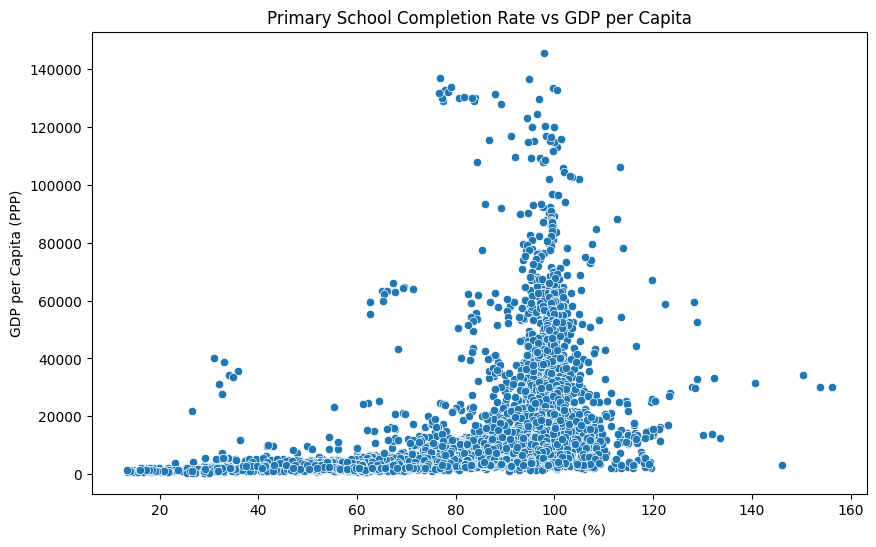

In [90]:
#scatterplot of PSCR vs GDP per Capita
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='PSCR', y='GDP per Capita')
plt.title('Primary School Completion Rate vs GDP per Capita')
plt.xlabel('Primary School Completion Rate (%)')
plt.ylabel('GDP per Capita (PPP)')

C:\Users\adaad\AppData\Local\Temp\ipykernel_18972\1084043020.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["log_GDP per Capita"] = np.log(df_clean["GDP per Capita"])


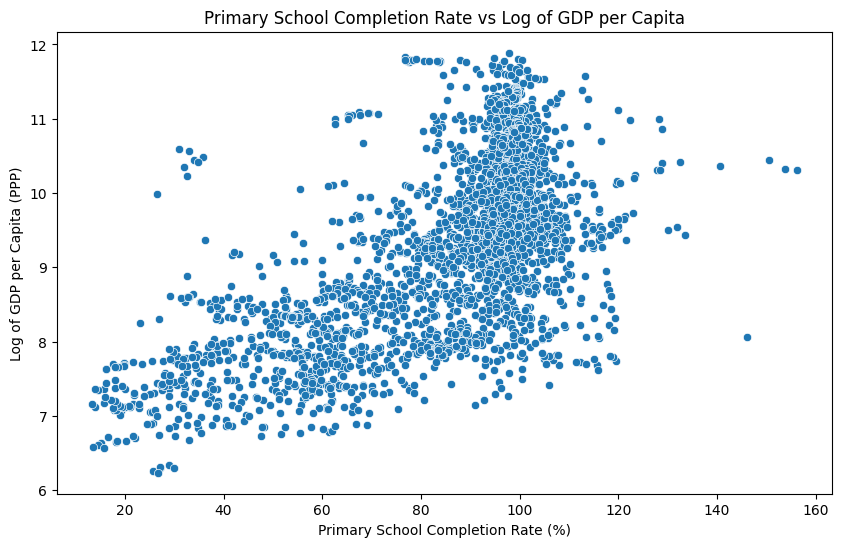

In [96]:
#transformation of GDP per Capita

df_clean["log_GDP per Capita"] = np.log(df_clean["GDP per Capita"])
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='PSCR', y='log_GDP per Capita')
plt.title('Primary School Completion Rate vs Log of GDP per Capita')
plt.xlabel('Primary School Completion Rate (%)')
plt.ylabel('Log of GDP per Capita (PPP)')
plt.show()

In [ ]:
#linear model on log GDP per Capita and PSCR
X = df_clean[['log_GDP per Capita']] #predictor
y = df_clean['PSCR']

model = LinearRegression()
model.fit(X, y)




,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [99]:
y_pred = model.predict(X)

y_pred

array([93.38775782, 93.11176776, 92.81664929, ..., 72.35548667,
       73.59169641, 73.98434434], shape=(3121,))

In [110]:
# Calculate Stats
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)


In [106]:
print("\nModel Results ")
print(f"Slope (Coefficient): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r2:.4f}")
print("Interpretation: A 1% increase in GDP is associated with a " f"{slope/100:.4f} point increase in completion rate.")


Model Results 
Slope (Coefficient): 12.0290
Intercept: -26.4807
R-squared: 0.4209
Interpretation: A 1% increase in GDP is associated with a 0.1203 point increase in completion rate.


Machine Learning


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [113]:
X = df_clean[['log_GDP per Capita']] #predictor
y = df_clean['PSCR']

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
lm = LinearRegression()
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [130]:
y_pred_test = lm.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_train = lm.score(X_train, y_train)
r2_test = r2_score(y_test, y_pred_test)

322.7346248115643

In [132]:
print("--- Machine Learning Evaluation ---")
print(f"Model Intercept: {lm.intercept_:.2f}")
print(f"Model Slope:     {lm.coef_[0]:.2f}")
print("-" * 30)
print(f"Training R²:     {r2_train:.4f} (How well it learned known data)")
print(f"Testing R²:      {r2_test:.4f} (How well it generalizes to new data)")
print(f"RMSE:            {rmse:.2f} (Average error in percentage points)")

--- Machine Learning Evaluation ---
Model Intercept: -26.58
Model Slope:     12.03
------------------------------
Training R²:     0.4319 (How well it learned known data)
Testing R²:      0.3802 (How well it generalizes to new data)
RMSE:            17.96 (Average error in percentage points)


c:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


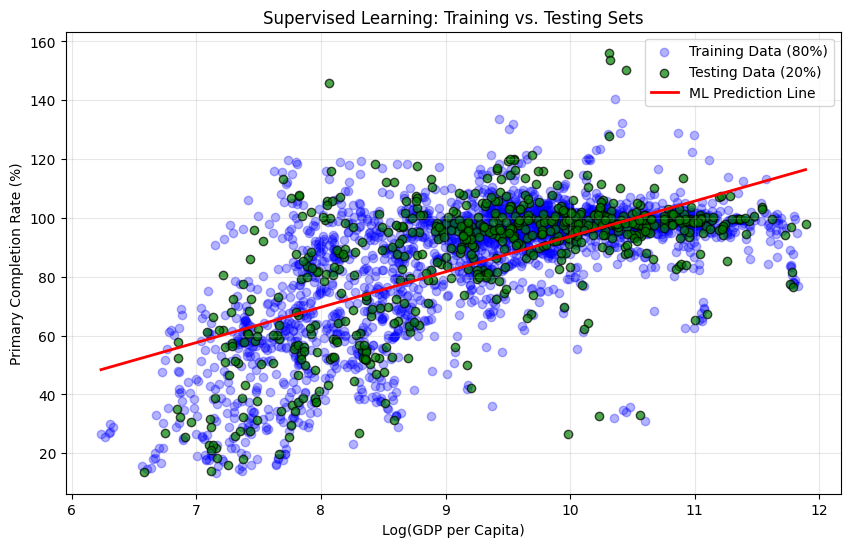

In [ ]:
plt.figure(figsize=(10, 6))

# Plot Training Data (Blue)
plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Training Data (80%)')

# Plot Testing Data (Green)
plt.scatter(X_test, y_test, color='green', alpha=0.7, edgecolors='black', label='Testing Data (20%)')

# Plot the Regression Line (based on model)
line_x = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
line_y = lm.predict(line_x)
plt.plot(line_x, line_y, color='red', linewidth=2, label='ML Prediction Line')

plt.title('Supervised Learning: Training vs. Testing Sets')
plt.xlabel('Log(GDP per Capita)')
plt.ylabel('Primary Completion Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Text(0, 0.5, 'Residuals (Error)')

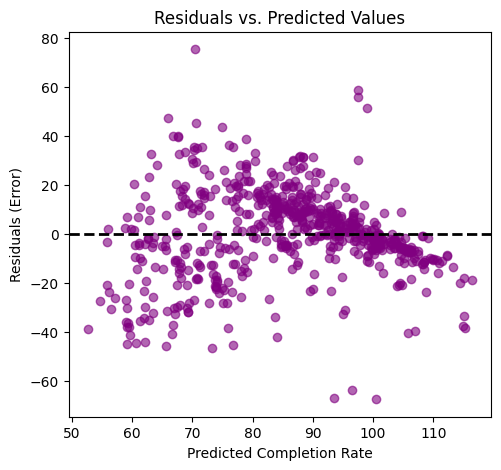

In [134]:
resid = y_test - y_pred_test
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, resid, alpha=0.6, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2) # The "Zero Error" line
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Completion Rate')
plt.ylabel('Residuals (Error)')

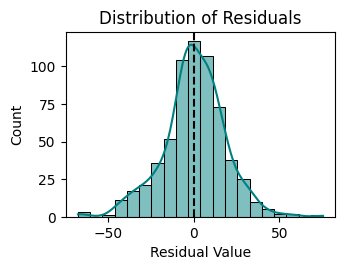

In [140]:
plt.subplot(2, 2, 2)
sns.histplot(resid, kde=True, color='teal', bins=20)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.axvline(x=0, color='black', linestyle='--') # Center line

plt.tight_layout()
plt.show()

In [126]:
print("--- Residual Analysis ---")
print(f"Mean of Residuals: {np.mean(resid):.4f} (Should be close to 0)")
print(f"Std Dev of Residuals: {np.std(resid):.4f}")

--- Residual Analysis ---
Mean of Residuals: 0.4699 (Should be close to 0)
Std Dev of Residuals: 17.9587


Random Forest Regressor

In [143]:
from sklearn.ensemble import RandomForestRegressor

In [144]:
X = df_clean[['log_GDP per Capita']] #predictor
y = df_clean['PSCR']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [145]:
# 2. Train the Random Forest Model
# n_estimators=100 means we are building 100 trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [164]:
# 3. Predict & Evaluate
y_pred_rf = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mean_squared_error(y_test, y_pred_rf)

352.1678165268733

In [147]:
print("--- Model Comparison ---")
print(f"Linear Model R²:       {r2_test:.4f}") # Assumed from previous step
print(f"Random Forest R²:      {rf_r2:.4f}")
print(f"Random Forest RMSE:    {rf_rmse:.2f}")

--- Model Comparison ---
Linear Model R²:       0.3802
Random Forest R²:      0.3237
Random Forest RMSE:    18.77


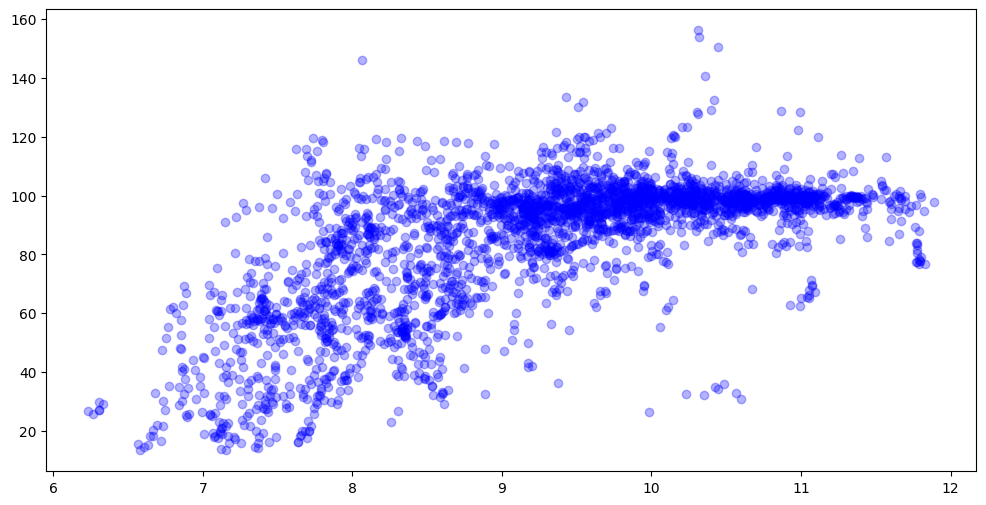

In [163]:
# 4. Visualization: The "Staircase" vs. The "Curve"

plt.figure(figsize=(12, 6))

# Plot actual data
plt.scatter(df_clean['log_GDP per Capita'], df_clean['PSCR'], color='blue', alpha=0.3, label='Actual Data')

c:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


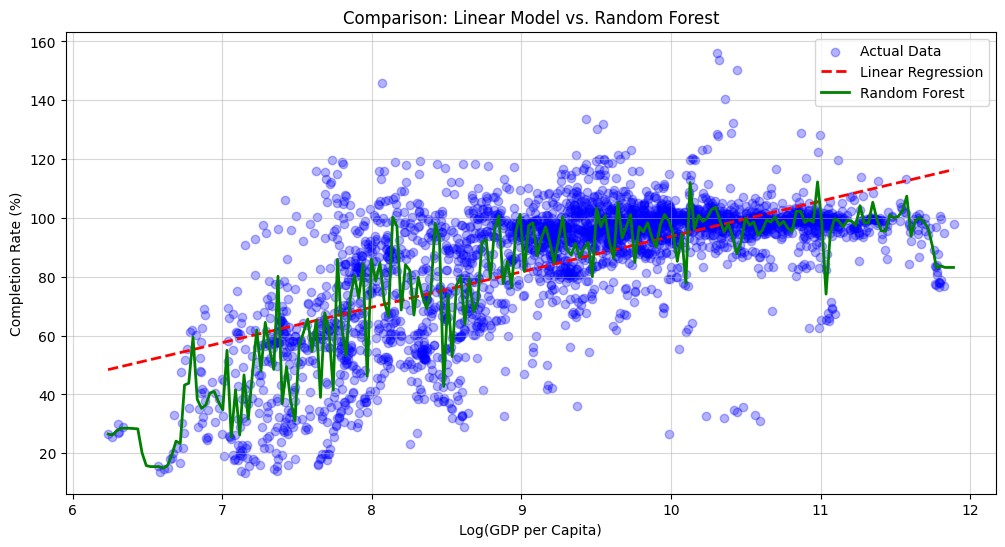

In [165]:
# Generate a smooth range of GDP values for plotting lines

plt.figure(figsize=(12, 6))

# Plot actual data
plt.scatter(df_clean['log_GDP per Capita'], df_clean['PSCR'], color='blue', alpha=0.3, label='Actual Data')
X_range = np.linspace(X['log_GDP per Capita'].min(), X['log_GDP per Capita'].max(), 200).reshape(-1, 1)

# Linear Prediction Line
y_linear_range = lm.predict(X_range)
plt.plot(X_range, y_linear_range, color='red', linewidth=2, linestyle='--', label='Linear Regression')
# Random Forest Prediction Line
y_rf_range = rf_model.predict(X_range)
plt.plot(X_range, y_rf_range, color='green', linewidth=2, label='Random Forest')

plt.title('Comparison: Linear Model vs. Random Forest')
plt.xlabel('Log(GDP per Capita)')
plt.ylabel('Completion Rate (%)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()